In [4]:
%matplotlib widget

In [5]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [6]:
spectra = []

for i in range(1, 21):
    df = pd.read_csv(f"Spectrum_{i}_gas_exp.csv")
    spectra.append(df)

In [7]:
def Ku03(x):
    # AGN selection based on Kauffman et al. 2003
    # log OIII/Hb > 0.61/(log NII/Ha - 0.05) + 1.3
    return 0.61/(x - 0.05) + 1.3

def Ke01(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.61/(log NII/Ha - 0.47) + 1.19
     return 0.61/(x - 0.47) + 1.19

def S06(x):
    # AGN selection based on Stasinska et al 2006
     # log OIII/Hb > 0.29/(log NII/Ha +0.20) + 0.96
    return 0.29/(x + 0.20) + 0.96

def C10(x):
 # Seyfert–LINER line based on Cid Fernandes et al 2010
    return 1.01*x + 0.48

def Ke01_SII(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.72/(log SII/Ha - 0.32) + 1.3
     return 0.72/(x - 0.32) + 1.3

def Ke06(x):
    #Seyfert–LINER line
    return 1.89* x + 0.76

def error_ratio(err_1, err_2, flux_1, flux_2):
    try:
        e_1 = err_1 / (flux_1 * np.log(10)) if flux_1 != 0 else np.nan
        e_2 = err_2 / (flux_2 * np.log(10)) if flux_2 != 0 else np.nan
        return np.sqrt(e_1**2 + e_2**2)
    except:
        return np.nan

def ratio(spectrum_1):
    flux = spectrum_1['Flux']
    err_flux = spectrum_1['Error_flux']

    OIII = flux[8]
    HB   = flux[1]
    NII  = flux[12]
    HA   = flux[2]
    SII  = flux[3]

    OIII_HB = np.log10(OIII / HB) if OIII > 0 and HB > 0 else np.nan
    NII_HA  = np.log10(NII / HA)  if NII > 0 and HA > 0 else np.nan
    SII_HA  = np.log10(SII / HA)  if SII > 0 and HA > 0 else np.nan

    err_OIII_HB = error_ratio(err_flux[8], err_flux[1], OIII, HB)
    err_NII_HA  = error_ratio(err_flux[12], err_flux[2], NII, HA)
    err_SII_HA  = error_ratio(err_flux[3], err_flux[2], SII, HA)

    return OIII_HB, NII_HA, SII_HA, err_OIII_HB, err_NII_HA, err_SII_HA

0.5628527522078518 0.051257450381372034 -0.07950360701556215
1.0676459194164334 -0.6295921323271653 -0.923161328325605
-0.06402849729732749 -0.46927889280781704 -0.7480857714695319
-0.07016262105483091 -0.5063150277018138 -0.8871346779417987
-0.17735110886034633 -0.4963964593356815 -0.8620748492909583
-0.2535741091688197 -0.3859411651901994 -0.9833545279463655
-0.17826540771864194 -0.3736248353601309 -0.8690627002685176
-0.16485577220594536 -0.40332629702895156 -0.7557656532400143
-0.019043209533121736 -0.43622090129960506 -0.8830130109913353
-0.04803599183303478 -0.48354219504809504 -0.8900285912899314
0.12967539589029753 -0.48153494447863293 -0.7115098738008037
0.13501801155532306 -0.4934194330654934 -0.6571733194384937
0.06772782400261386 -0.4686024492469175 -0.65796361654066
0.08492988974896407 -0.2673830604191721 -0.5086914187172935
-0.7607162158981104 -2.0895840198326288 -0.964245213847238
nan -0.981736484029496 nan


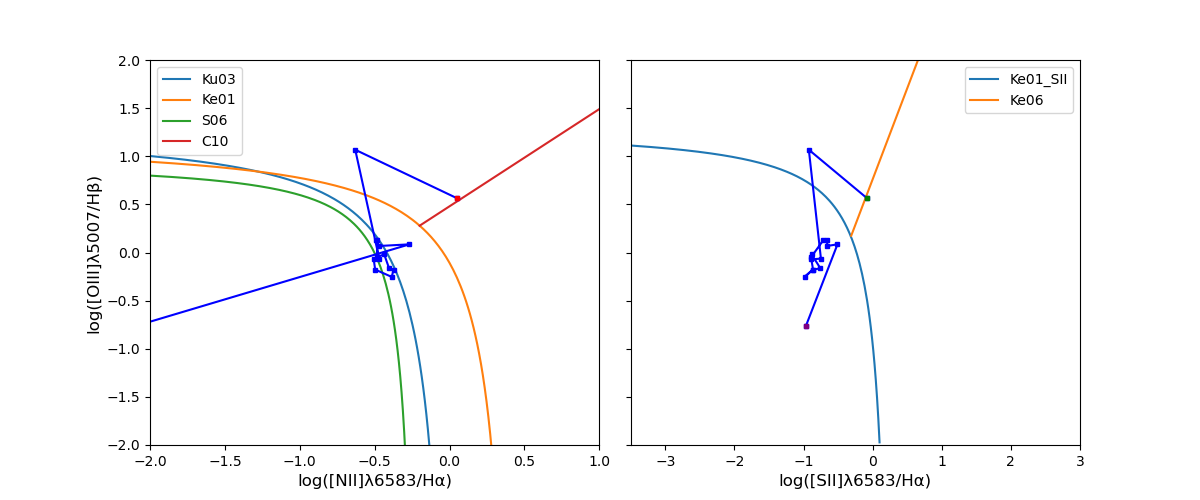

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.2, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'Ku03')
ax[0].plot(x1, Ke01(x1), label = 'Ke01')
ax[0].plot(x2, S06(x2), label = 'S06')
ax[0].plot(x3, C10(x3), label = 'C10')

x = np.linspace(-3.5, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01_SII')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')

NII_HA =[]
OIII_HB =[]
SII_HA =[]
OIII_HB_ok2 =[]
for i in range(2, 18):
    spectrum = spectra[i]
    oiii_hb, nii_ha, sii_ha, err_oiii_hb, err_nii_ha, err_sii_ha = ratio(spectrum)
    print(oiii_hb, nii_ha, sii_ha)
    NII_HA.append(nii_ha)
    OIII_HB.append(oiii_hb)
    if np.isnan(oiii_hb) == False and np.isnan(sii_ha) == False:
        SII_HA.append(sii_ha)
        OIII_HB_ok2.append(oiii_hb)
    
ax[0].plot(NII_HA, OIII_HB, color='blue', marker= 's', linestyle='-', markersize = 3)   
ax[0].plot(NII_HA[0], OIII_HB[0], color='red', marker= 's', linestyle='-', markersize = 3) 
ax[0].plot(NII_HA[-1], OIII_HB[-1], color='orange', marker= 's', linestyle='-', markersize = 3) 
ax[1].plot(SII_HA, OIII_HB_ok2, color='blue', marker= 's', linestyle='-', markersize = 3)
ax[1].plot(SII_HA[0], OIII_HB_ok2[0], color='green', marker= 's', linestyle='-', markersize = 3)
ax[1].plot(SII_HA[-1], OIII_HB_ok2[-1], color='purple', marker= 's', linestyle='-', markersize = 3)

ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

ax[1].set_xlim(-3.5, 3)
ax[1].set_ylim(-2, 2)
ax[1].set_xlabel('log([SII]λ6583/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.07)
plt.savefig('BPT_grad.png', bbox_inches='tight')